# RAGAS 사용해보기

RAGAS의 사용을 위해서는 다음과 같이 준비해주세요  

In [ ]:
# [실습 환경 준비]
# Ragas 및 LangChain 관련 최신 패키지를 설치합니다.
!pip install -qU ragas langchain langchain-openai langchain-community chromadb tiktoken nest_asyncio pandas

# RAGAS는 평가 속도를 높이기 위해 내부적으로 asyncio.gather를 사용해 수백 개의 API를 동시에 비동기 호출합니다.
# Jupyter/Colab 환경은 이미 자체적인 비동기 이벤트 루프를 돌리고 있어서 충돌이 발생합니다.
# nest_asyncio는 이 충돌을 막아주어 Colab에서도 RAGAS가 병렬 처리를 할 수 있게 해줍니다.
import nest_asyncio
nest_asyncio.apply()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17

데이터는 총 4가지를 준비합니다.  
  
- question : 사용자의 질문

- ground truth : 질문에 맞는 정답 (= 모범 답안)

- answer : LLM이 생성한 답변

- context : LLM이 답변을 생성하기 위해 참고한 정보 (=context)

허깅페이스 데이터셋을 구축하는 식으로, 데이터셋을 구축해야합니다.  
불장을 놓친 억울함을 기리며 주식 데이터로 예시를 구축해봤습니다.

In [ ]:
questions = ["주가수익비율(PER)이란 무엇이며 어떻게 계산하나요?"]
ground_truths = ["주가수익비율(PER)은 기업의 주가를 주당순이익(EPS)으로 나눈 값으로, 해당 기업의 주가가 실제 수익에 비해 얼마나 높게 형성되어 있는지를 나타내는 지표입니다. 이는 투자자들이 기업의 이익 1원을 얻기 위해 지불하는 비용을 의미하며, 보통 업종 평균 PER과 비교하여 저평가 혹은 고평가 여부를 판단합니다."]
answers = ["PER(Price Earnings Ratio)은 현재 주가를 주당순이익(EPS)으로 나눈 비율을 의미합니다. 여기서 주가는 시장에서 거래되는 가격을 말하며, 주당순이익(EPS)은 기업이 벌어들인 순이익을 발행 주식 수로 나눈 값입니다. PER이 낮을수록 해당 기업이 벌어들이는 이익에 비해 주가가 저렴하다는 '저평가' 신호로 해석될 수 있으며, 반대로 높으면 '고평가' 혹은 미래 성장성이 높다고 판단합니다."]
contexts = [[
    "A: 주가수익비율(PER)은 현재 주가를 1주당 예상 순이익(EPS)으로 나눈 수치로, 기업의 수익성 대비 주가 수준을 평가하는 핵심 지표입니다. "
    "* EPS(Earnings Per Share): 기업이 벌어들인 당기순이익을 발행주식 총수로 나눈 값. "
    "** 업종 평균 PER: 동일 산업군 내 기업들의 PER을 평균낸 값으로, 개별 기업의 상대적 가치를 판단하는 기준이 됨. "
    "\n\n"
    "| 종목명 | 현재가 | EPS | PER | 업종평균 PER | 투자판단 |"
    "| :--- | :--- | :--- | :--- | :--- | :--- |"
    "| 삼성전자 | 75,000 | 5,000 | 15.0x | 18.2x | 저평가 |"
    "| SK하이닉스 | 180,000 | 9,000 | 20.0x | 18.2x | 고평가(성장세) |"
    "| 현대차 | 250,000 | 35,000 | 7.1x | 10.5x | 저평가 |"
    "| 카카오 | 50,000 | 500 | 100.0x | 45.0x | 고평가 |"
]]

In [ ]:
from datasets import Dataset
import pandas as pd

# To dict
data = {
  "user_input": questions,
  "response": answers,
  "retrieved_contexts": contexts,
  "reference": ground_truths
}

# Convert dict to dataset
dataset = Dataset.from_dict(data)

OpenAI API key를 등록합니다.

In [ ]:
import os

In [ ]:
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

In [ ]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
)



/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_314/2157021597.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_314/2157021597.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (

다음과 같이 간단하게, 위에서 소개한 메트릭을 적용할 수 있습니다.  

In [ ]:
result = evaluate(
    dataset = dataset,
    metrics=[
        context_precision,
        context_recall,
        faithfulness,
        answer_relevancy,
    ],
)

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[3]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')


In [ ]:
# score 출력
print(result)
# DataFrame 생성
df = result.to_pandas()
df

{'context_precision': 1.0000, 'context_recall': 0.5000, 'faithfulness': 0.8000, 'answer_relevancy': nan}


,user_input,retrieved_contexts,response,reference,context_precision,context_recall,faithfulness,answer_relevancy
0,주가수익비율(PER)이란 무엇이며 어떻게 계산하나요?,[A: 주가수익비율(PER)은 현재 주가를 1주당 예상 순이익(EPS)으로 나눈 수...,PER(Price Earnings Ratio)은 현재 주가를 주당순이익(EPS)으로...,"주가수익비율(PER)은 기업의 주가를 주당순이익(EPS)으로 나눈 값으로, 해당 기...",1.0,0.5,0.8,NaN


LLM 세팅을 다음과 같이 커스터마이징하여 사용할 수도 있습니다.  

In [ ]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

In [ ]:
# 판사(Judge) 역할을 할 LLM과 임베딩 세팅
evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
evaluator_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [ ]:
# 평가용 가상 데이터셋
data_samples = {
    "question": [
        "프랑스의 수도는 어디이며, 가장 유명한 미술관은 무엇인가요?",
        "블랙홀의 사건의 지평선이란 무엇인가요?"
    ],
    "contexts": [
        [
            "파리는 프랑스의 수도이자 세계적인 문화 중심지입니다.",
            "루브르 박물관은 파리에 위치해 있으며, 모나리자와 같은 명작을 소장하고 있습니다."
        ],
        [
            "블랙홀은 중력이 너무 강해 빛조차 빠져나갈 수 없는 천체입니다.",
            "우주 공간에는 수많은 블랙홀이 존재한다고 추정됩니다." # 의도적 누락: 사건의 지평선 설명 없음
        ]
    ],
    "answer": [
        "프랑스의 수도는 파리이며, 가장 유명한 미술관은 루브르 박물관입니다.",
        "블랙홀의 사건의 지평선은 중력이 너무 강해 빛조차 빠져나갈 수 없는 경계면을 의미합니다. 일반 상대성 이론에 의해 예측되었습니다." # RAG 관점의 환각 발생
    ],
    "ground_truth": [
        "프랑스의 수도는 파리이고, 대표적인 미술관은 루브르 박물관입니다.",
        "사건의 지평선(Event Horizon)은 블랙홀의 탈출 속도가 빛의 속도를 넘어서는 공간의 경계입니다."
    ]
}

evaluation_dataset = Dataset.from_dict(data_samples)

In [ ]:
# 결과 평가
result = evaluate(
    dataset=evaluation_dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    raise_exceptions=False # API 에러 발생 시 중단하지 않음
)

pd.set_option('display.max_colwidth', None)
df_result = result.to_pandas()
display(df_result[['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']])

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

,faithfulness,answer_relevancy,context_precision,context_recall
0,0.500000,0.561577,0.5,1.0
1,0.666667,0.302150,1.0,0.0


데이터셋을 간단하게 구축하여, RAGAS로 간단하게 평가할 수 있는 예제를 살펴보았습니다.  
이제 여러분들이 구축하시는 RAG 에 Question-Answer 쌍을 기록하여, 개선->테스트->평가 루프를 구축할 수 있습니다.  

**그런데 Ground Truth가 없을 때는 어떻게 하나요?**

RAGAS의 핵심 지표 중 Context Recall과 Context Precision을 계산하려면 반드시 인간이 작성한 완벽한 모범 답안, 즉 **ground_truth** 가 필요합니다.  
문제는 현업에서 수백 장의 사내 매뉴얼이나 PDF를 주고 *"이 문서를 바탕으로 예상 질문 100개와 정답 100개를 만들어 오세요"*라고 하면 엄청난 노가다가 발생한다는 것입니다! 평가를 위해 몇 주 동안 정답 세트만 만들고 있을 수는 없습니다.  

이를 해결하기 위해 RAGAS는 획기적인 기능을 제공합니다.  
**바로 평가용 데이터셋 자체를 LLM이 자동으로 만들어주는 기능 (Testset Generation) 입니다.**  

우리가 가진 원본 문서들(PDF, 텍스트)을 통째로 RAGAS 모델에 던져줍니다.  
RAGAS 내부의 LLM이 문서를 쓱 읽고, "아, 일반 사용자는 이런 걸 물어보겠네?", *"이 부분은 숫자가 복잡하니 추론형 질문을 만들어야겠다"*라며 스스로 질문(Question)을 만들어냅니다.  
그리고 자신이 질문을 만든 근거가 된 문서 조각을 정답 문서(Context)로 삼고, 이상적인 답변(Ground Truth)까지 작성하여 한 세트를 완성합니다.  
단 10줄의 코드로 사람이 몇 주 걸릴 '평가용 데이터셋'을 구축할 수 있습니다.  

다음 도큐먼트를 참조하여, 프로젝트에 활용해보시기 바랍니다!  


https://docs.ragas.io/en/stable/getstarted/rag_testset_generation/

## 마치며  

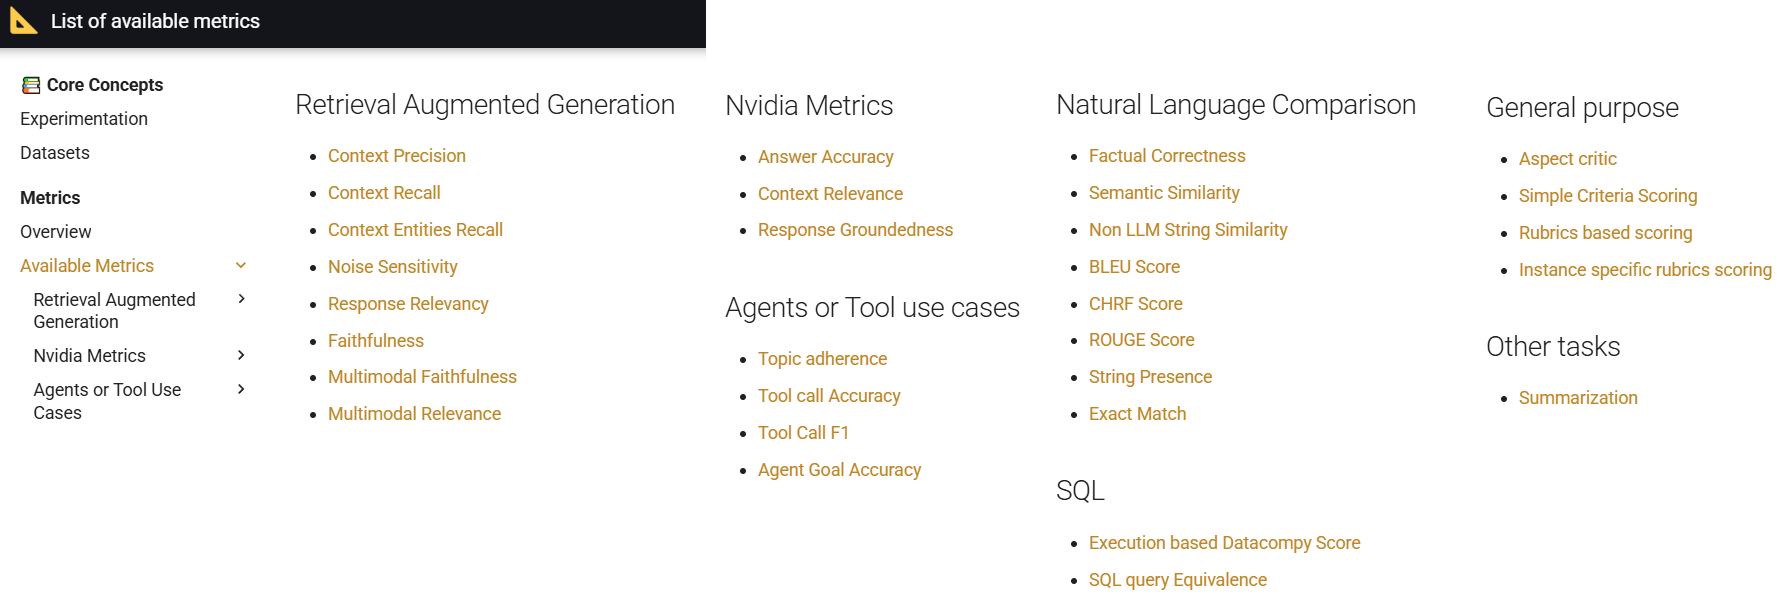

현업에서는 매트릭을 다양한 형태로 구성하고 있습니다.  
이런 요구에 맞춰, RAGAS에서는 BLEU/ROGUE 등의 전통적인 매트릭부터, Agent의 Action을 추적하는 매트릭까지 다양한 구성을 간편하게 불러올 수 있도록 지원하고 있습니다.  
https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/#other-tasks  

여러분들의 RAG도 태스크에 맞는 매트릭을 차용해, 더 견고하게 만들어보시기 바랍니다!  